In [2]:
! pip install pandas numpy matplotlib seaborn scikit-learn

  Obtaining dependency information for pandas from https://files.pythonhosted.org/packages/ed/8c/87ddf1fcb55d11f9f847e3c69bb1c6f8e46e2f40ab1a2d2abadb2401b007/pandas-2.2.3-cp311-cp311-win_amd64.whl.metadata
  Using cached pandas-2.2.3-cp311-cp311-win_amd64.whl.metadata (19 kB)
  Obtaining dependency information for numpy from https://files.pythonhosted.org/packages/31/0a/f354fb7176b81747d870f7991dc763e157a934c717b67b58456bc63da3df/numpy-2.2.6-cp311-cp311-win_amd64.whl.metadata
  Using cached numpy-2.2.6-cp311-cp311-win_amd64.whl.metadata (60 kB)
  Obtaining dependency information for matplotlib from https://files.pythonhosted.org/packages/a6/da/948a017c3ea13fd4a97afad5fdebe2f5bbc4d28c0654510ce6fd6b06b7bd/matplotlib-3.10.3-cp311-cp311-win_amd64.whl.metadata
  Using cached matplotlib-3.10.3-cp311-cp311-win_amd64.whl.metadata (11 kB)
  Obtaining dependency information for seaborn from https://files.pythonhosted.org/packages/83/11/00d3c3dfc25ad54e731d91449895a79e4bf2384dc3ac01809010ba88f6d5


[notice] A new release of pip is available: 23.2.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, learning_curve
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR

import pickle
import warnings
warnings.filterwarnings('ignore')


In [5]:
df = pd.read_csv('insurance.csv')
print("Форма данных:", df.shape)
df.head()


Форма данных: (1338, 7)


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520



Информация о данных:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB
None

Проверка пропущенных значений:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Статистическое описание:
               age          bmi     children       charges
count  1338.000000  1338.000000  1338.000000   1338.000000
mean     39.207025    30.663397     1.094918  13270.422265
std      14.049960     6.098187     1.205493  12110.011237
min      18.000000    15.960000     0.000000   1

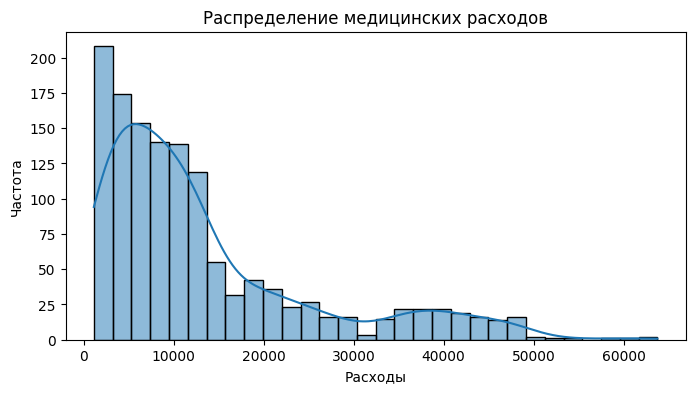

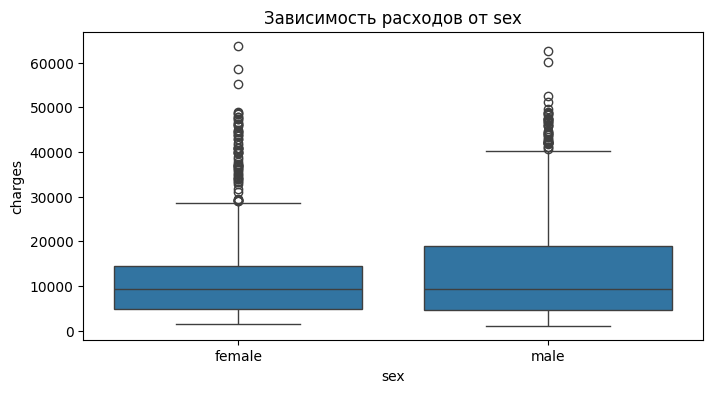

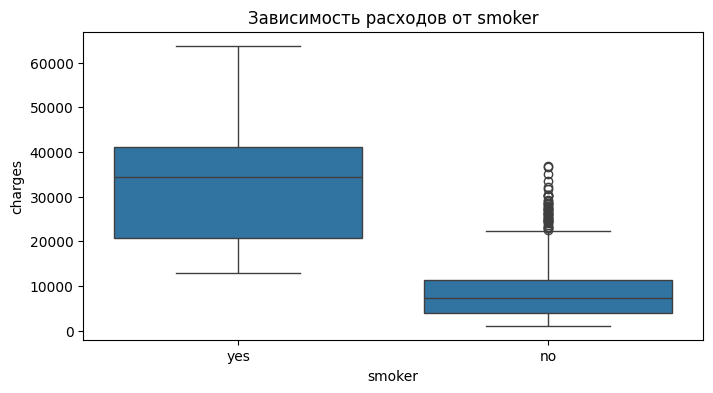

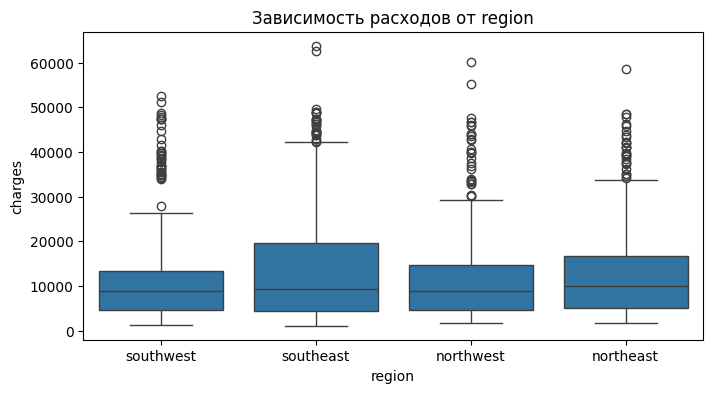

In [6]:
print("\nИнформация о данных:")
print(df.info())

print("\nПроверка пропущенных значений:")
print(df.isnull().sum())

print("\nСтатистическое описание:")
print(df.describe())

plt.figure(figsize=(8, 4))
sns.histplot(df['charges'], bins=30, kde=True)
plt.title('Распределение медицинских расходов')
plt.xlabel('Расходы')
plt.ylabel('Частота')
plt.show()

categorical_features = ['sex', 'smoker', 'region']
for feature in categorical_features:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=feature, y='charges', data=df)
    plt.title(f'Зависимость расходов от {feature}')
    plt.show()


In [7]:
# 3 -> Предобработка данных

X = df.drop('charges', axis=1)
y = df['charges']

numeric_features = ['age', 'bmi', 'children']
categorical_features = ['sex', 'smoker', 'region']

numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(drop='first'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])


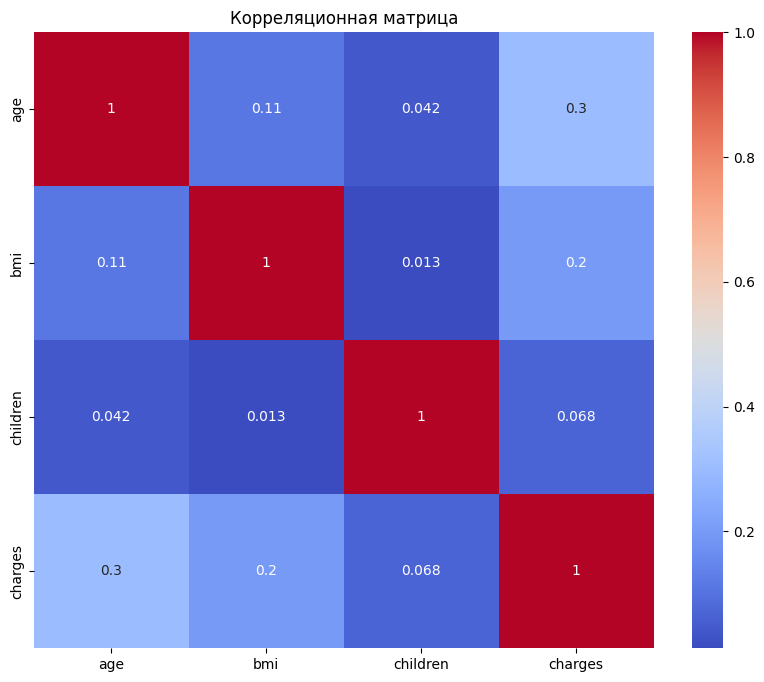

In [9]:
# 4 -> Корреляционный анализ

# Оставим только числовые столбцы
numeric_df = df.select_dtypes(include=[np.number])

plt.figure(figsize=(10, 8))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title("Корреляционная матрица")
plt.show()



In [10]:
# 6 -> Построение моделей
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42),
    'SVR': SVR()
}



In [12]:
# 7 -> Построение базовых моделей
baseline_results = []

for name, model in models.items():
    pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                               ('regressor', model)])
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)  # вручную берём корень
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    baseline_results.append({
        'Model': name,
        'RMSE': rmse,
        'MAE': mae,
        'R2': r2
    })


In [18]:
# 8 -> Подбор гиперпараметров
param_grids = {
    'Decision Tree': {'regressor__max_depth': [3, 5, 7, 9]},
    'Random Forest': {'regressor__n_estimators': [50, 100],
                      'regressor__max_depth': [4, 6, 8]},
    'Gradient Boosting': {'regressor__n_estimators': [50, 100],
                          'regressor__learning_rate': [0.05, 0.1]},
    'SVR': {'regressor__C': [0.1, 1, 10],
            'regressor__kernel': ['linear', 'rbf']}
}

# 8 -> Подбор гиперпараметров
tuned_results = []

for name in ['Decision Tree', 'Random Forest', 'Gradient Boosting', 'SVR']:
    pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                               ('regressor', models[name])])
    grid = GridSearchCV(pipeline, param_grids[name], cv=5, scoring='neg_mean_squared_error')
    grid.fit(X_train, y_train)
    
    best_model = grid.best_estimator_
    y_pred = best_model.predict(X_test)
    
    # ВАЖНО: пересчитать mse именно здесь
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    tuned_results.append({
        'Model': name,
        'RMSE': rmse,
        'MAE': mae,
        'R2': r2,
        'Best Params': grid.best_params_
    })




In [19]:
# 9 -> Оценка улучшенных моделей

import pandas as pd

baseline_df = pd.DataFrame(baseline_results)
tuned_df = pd.DataFrame(tuned_results)

print("Baseline Models:")
print(baseline_df)

print("\nTuned Models:")
print(tuned_df)


Baseline Models:
               Model          RMSE          MAE        R2
0  Linear Regression   5796.284659  4181.194474  0.783593
1      Decision Tree   6387.122471  3114.152909  0.737226
2      Random Forest   4567.775116  2543.975825  0.865606
3  Gradient Boosting   4329.570011  2443.483262  0.879257
4                SVR  12897.600111  8606.592261 -0.071494

Tuned Models:
               Model          RMSE          MAE        R2  \
0      Decision Tree   4776.261075  2865.637810  0.853057   
1      Random Forest   4477.715077  2602.289757  0.870853   
2  Gradient Boosting   4294.455210  2473.410271  0.881208   
3                SVR  12176.145062  6125.470827  0.045026   

                                         Best Params  
0                        {'regressor__max_depth': 3}  
1  {'regressor__max_depth': 4, 'regressor__n_esti...  
2  {'regressor__learning_rate': 0.05, 'regressor_...  
3  {'regressor__C': 10, 'regressor__kernel': 'lin...  


In [20]:
# 10 -> Сохранение лучшей модели
best_model_info = min(tuned_results, key=lambda x: x['RMSE'])
print(f"Лучшая модель: {best_model_info['Model']} с RMSE: {best_model_info['RMSE']}")

# Сохраняем модель
with open('best_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)


Лучшая модель: Gradient Boosting с RMSE: 4294.455209765922


In [ ]:
# 11 -> Создание веб-приложения